# NB3 · Customer Segmentation

**Goal**: Group customers into meaningful behavioural segments — not random clusters, but ones that make business sense.  
We do this in two ways:
1. **Rule-based segmentation** — using business logic (contract type × tenure × charges) to label cohorts.
2. **K-Means clustering** — let the data surface natural groupings from numeric features.

Each segment gets a churn rate and an average monthly spend → feeds directly into the retention strategy in NB5.

**Requires**: `telco_clean.csv` produced by NB1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('telco_clean.csv')
print(f'Loaded {df.shape[0]:,} rows')

Loaded 7,043 rows


## 1 · Rule-based segments

We combine two strong signals — contract type and tenure — to define four intuitive segments:

| Segment | Logic | Expected churn |
|---------|-------|----------------|
| New & vulnerable | M2M + tenure ≤ 12 | Very high |
| Established M2M | M2M + tenure > 12 | High |
| Long-term contract | 1yr or 2yr | Low |
| Power users | Any + MonthlyCharges > 75th percentile | Mixed |

In [2]:
q75 = df['MonthlyCharges'].quantile(0.75)

def segment(row):
    if row['Contract'] == 'Month-to-month' and row['tenure'] <= 12:
        return 'New & vulnerable'
    elif row['Contract'] == 'Month-to-month' and row['tenure'] > 12:
        return 'Established M2M'
    elif row['MonthlyCharges'] >= q75:
        return 'Power user'
    else:
        return 'Long-term contract'

df['segment'] = df.apply(segment, axis=1)

seg_summary = df.groupby('segment').agg(
    n=('customerID', 'count'),
    churn_rate=('Churn_flag', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean')
).round(2)
seg_summary['churn_rate'] = seg_summary['churn_rate'].mul(100).round(1)
print(seg_summary.sort_values('churn_rate', ascending=False))

                       n  churn_rate  avg_monthly  avg_tenure
segment                                                      
New & vulnerable    1994        51.0        58.22        4.47
Established M2M     1881        34.0        75.07       32.41
Power user           894        14.0       103.29       59.46
Long-term contract  2274         4.0        46.83       46.15


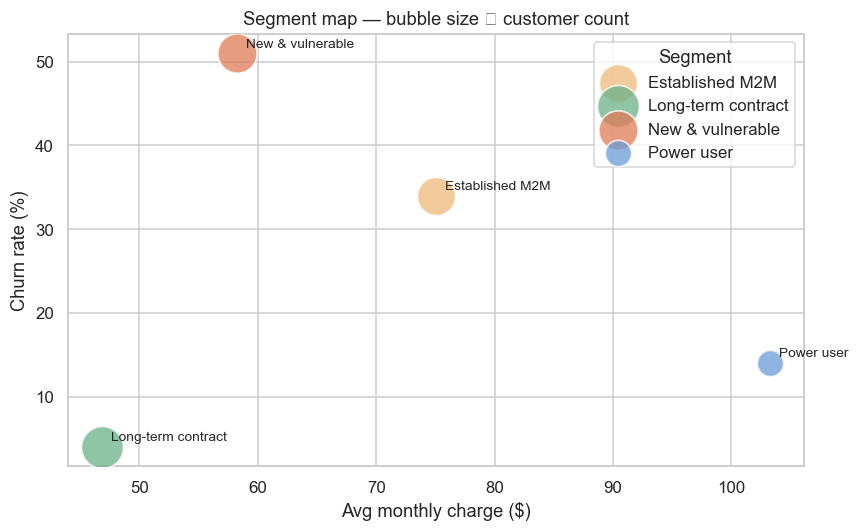

In [3]:
# Bubble chart: x = avg_monthly, y = churn_rate, size = n
fig, ax = plt.subplots(figsize=(8, 5))
palette = {'New & vulnerable': '#e07b54', 'Established M2M': '#f0b97a',
           'Power user': '#6a9bd8', 'Long-term contract': '#6ab187'}

for seg, row in seg_summary.iterrows():
    ax.scatter(row['avg_monthly'], row['churn_rate'],
               s=row['n'] / 3, alpha=0.75, color=palette.get(seg, 'gray'),
               edgecolors='white', linewidth=1.2, label=seg, zorder=3)
    ax.annotate(seg, xy=(row['avg_monthly'], row['churn_rate']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Avg monthly charge ($)')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Segment map — bubble size ∝ customer count')
ax.legend(title='Segment', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 2 · Service bundle analysis

Customers with more services have lower churn — but which bundles are most 'sticky'?  
We count how many add-on services each customer has, then plot churn rate by service count.

               mean  count
service_count             
0              21.4   2219
1              45.8    966
2              35.8   1033
3              27.4   1118
4              22.3    852
5              12.4    571
6               5.3    284


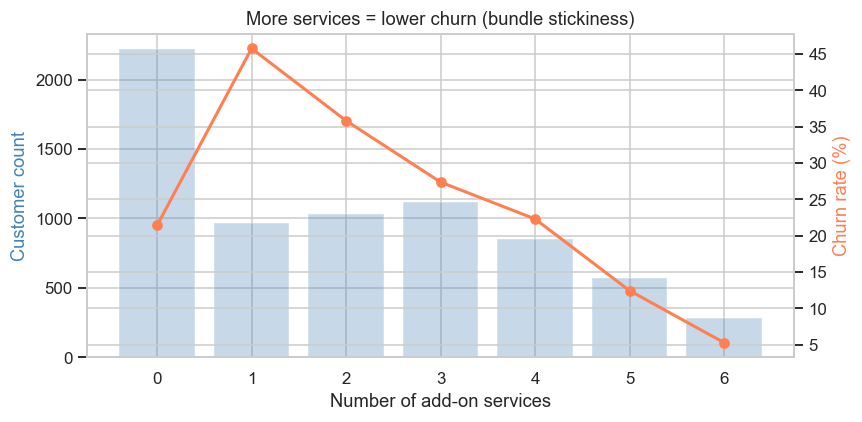

In [4]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df[col + '_bin'] = (df[col] == 'Yes').astype(int)

df['service_count'] = df[[c + '_bin' for c in service_cols]].sum(axis=1)

bundle_churn = df.groupby('service_count')['Churn_flag'].agg(['mean', 'count'])
bundle_churn['mean'] = bundle_churn['mean'].mul(100)
print(bundle_churn.round(1))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(bundle_churn.index, bundle_churn['count'], alpha=0.3, color='steelblue', label='Customer count')
ax2.plot(bundle_churn.index, bundle_churn['mean'], marker='o', color='coral', linewidth=2, label='Churn rate')
ax1.set_xlabel('Number of add-on services')
ax1.set_ylabel('Customer count', color='steelblue')
ax2.set_ylabel('Churn rate (%)', color='coral')
ax1.set_title('More services = lower churn (bundle stickiness)')
plt.tight_layout()
plt.show()

## 3 · K-Means data-driven clustering

We let the algorithm find clusters from numeric features: `tenure`, `MonthlyCharges`, `TotalCharges`, `service_count`.  
We use the **elbow method** to choose k, then visualise clusters in 2D via PCA.

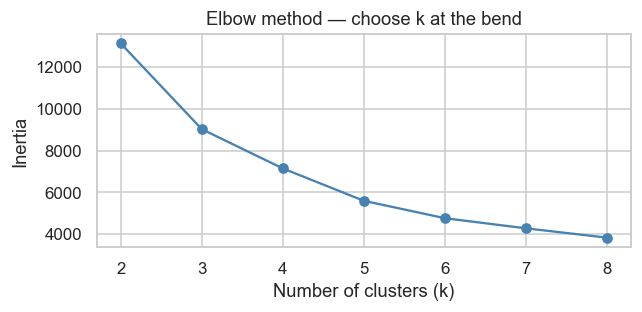

In [5]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'service_count']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(k_range), inertias, marker='o', color='steelblue')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method — choose k at the bend')
plt.tight_layout()
plt.show()

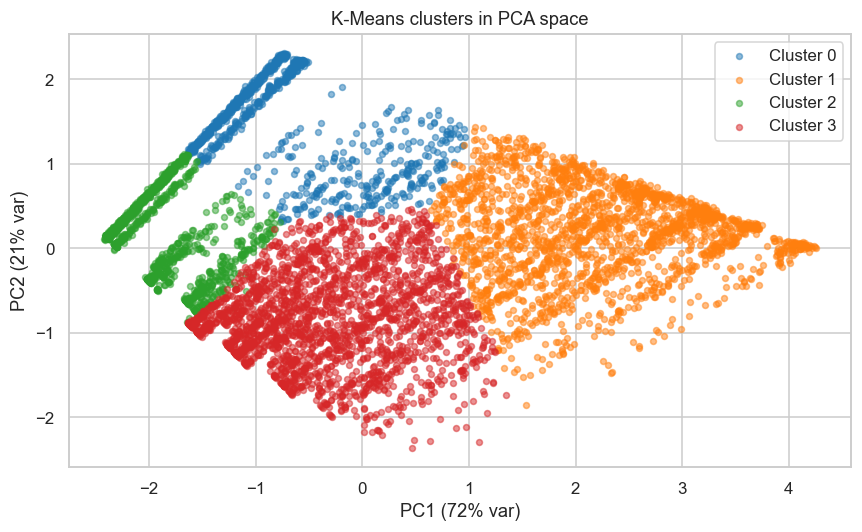

In [6]:
# Fit with chosen k (adjust based on elbow plot)
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init='auto')
df['cluster'] = km.fit_predict(X_scaled)

# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df['pca_1'] = coords[:, 0]
df['pca_2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette('tab10', K)
for k in range(K):
    mask = df['cluster'] == k
    ax.scatter(df.loc[mask, 'pca_1'], df.loc[mask, 'pca_2'],
               s=15, alpha=0.5, color=palette[k], label=f'Cluster {k}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} var)')
ax.set_title('K-Means clusters in PCA space')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Cluster profiles
cluster_profile = df.groupby('cluster').agg(
    n=('customerID', 'count'),
    churn_rate=('Churn_flag', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_services=('service_count', 'mean')
).round(2)
cluster_profile['churn_rate'] = cluster_profile['churn_rate'].mul(100).round(1)
print(cluster_profile.sort_values('churn_rate', ascending=False))

            n  churn_rate  avg_tenure  avg_monthly  avg_services
cluster                                                         
3        2475        46.0       15.68        77.73          1.99
2        1529        24.0        9.97        29.82          0.30
1        2067        15.0       58.79        91.18          4.07
0         972         5.0       53.92        30.51          0.57


## 4 · Export with segments

Save the enriched dataframe for use in NB4 (revenue) and NB5 (retention).

In [8]:
df.to_csv('telco_segmented.csv', index=False)
print('Saved telco_segmented.csv')

Saved telco_segmented.csv
